In [1]:
import gensim
from gensim.models.callbacks import CallbackAny2Vec

In [2]:
class callback(CallbackAny2Vec):
    '''Callback to print loss after each epoch.'''

    def __init__(self):
        self.epoch = 1
        self.loss_to_be_subed = 0
        
    def on_epoch_begin(self, model):
        print(f'Epoch: {self.epoch}', end='\t')

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        loss_now = loss - self.loss_to_be_subed
        self.loss_to_be_subed = loss
        print('Loss after {}- epoch: {}'.format(self.epoch, loss_now))
        self.epoch += 1

In [3]:
class LossLogger(CallbackAny2Vec):
    '''Output loss at each epoch'''
    def __init__(self):
        self.epoch = 1
        self.losses = []

    def on_epoch_begin(self, model):
        print(f'Epoch: {self.epoch}', end='\t')

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.losses == []:
            loss_value = int(loss)
        else:
            loss_value = int(loss - self.losses[-1])
        pretty_loss_value = format(loss_value, ',d')      
        print(f'Loss:\t{pretty_loss_value}\t{loss_value}')
        self.losses.append(loss)
        self.epoch += 1

In [4]:
corpus_sentences = gensim.models.word2vec.PathLineSentences('annotated_corpus', max_sentence_length=100_000)

In [5]:
SIZE = 300 # vector_size
CONTEXT_WINDOW = 30 # window (def=5)
MIN_COUNT = 1 # min_count (def=5)
WORKERS = 12 # workers - worker threads (def=3)
CBOW = 1 # sg, if 1 - skip-gram; if 0 - CBOW (def=0=CBOW)
SOFTMAX = 0 # hs, if 1 - hierarchical softmax; if 0 - negative sampling (def=0)
NOISE_WORDS = 5 # negative; if hs=0, specifies how many “noise words” should be drawn: usually between 5-20 (def=5)
NS_EXPONENT = 0.75 # ns_exponent: for hs=0, default (def=0.75)
CBOW_MEAN = 1 # cbow_mean: 0 - sum of the context word vectors; 1 - mean (def=1)
EPOCHS = 10 # epochs (def=5)
SHRINK = True # shrink_windows: If True, the effective window size is uniformly sampled from [1, window] for each target word 
          # during training, to match the original word2vec algorithm’s approximate weighting of context words by distance. 
           # Otherwise, the effective window size is always fixed to window words to either side.

In [6]:
loss_logger = LossLogger()
model = gensim.models.word2vec.Word2Vec(
    sentences=corpus_sentences, 
    vector_size=SIZE,
    window=CONTEXT_WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    sg=CBOW,
    hs=SOFTMAX,
    negative=NOISE_WORDS,
    ns_exponent=NS_EXPONENT,
    epochs=EPOCHS,
    seed=40302002, 
    compute_loss=True, 
    shrink_windows=SHRINK,
#     sample=0 # DEFAULT = 0.001
    callbacks=[loss_logger])

Epoch: 1	Loss:	5,215,749	5215749
Epoch: 2	Loss:	3,982,377	3982377
Epoch: 3	Loss:	3,509,744	3509744
Epoch: 4	Loss:	3,287,335	3287335
Epoch: 5	Loss:	2,723,439	2723439
Epoch: 6	Loss:	2,896,908	2896908
Epoch: 7	Loss:	2,665,436	2665436
Epoch: 8	Loss:	2,558,248	2558248
Epoch: 9	Loss:	2,814,294	2814294
Epoch: 10	Loss:	2,655,488	2655488


In [7]:
model.save('model.model')

In [8]:
from gensim.models import Word2Vec
model = Word2Vec.load('model.model')

In [25]:
model.wv.similarity("куст_NOUN", "дерево_NOUN")

0.24440117

In [26]:
model.wv.similarity("куст_NOUN", "сажать_VERB")

0.20885317

In [27]:
model.wv.most_similar("куст_NOUN")

[('цветущий_ADJ', 0.6525189280509949),
 ('сиреневый_ADJ', 0.6094385981559753),
 ('побегами_NOUN', 0.5746128559112549),
 ('укорениться_VERB', 0.5732070803642273),
 ('поврежденными_ADJ', 0.5717980861663818),
 ('пересаженным_ADJ', 0.5655716061592102),
 ('цвести_VERB', 0.5647737383842468),
 ('откажитесь_VERB', 0.5639504790306091),
 ('чахлый_ADJ', 0.5619679093360901),
 ('сирени_NOUN', 0.5613287687301636)]

In [28]:
model.wv.most_similar("дерево_NOUN")

[('птичник_PROPN', 0.5026675462722778),
 ('антисептик_PROPN', 0.480109304189682),
 ('благородность_NOUN', 0.4684469401836395),
 ('природа_PROPN', 0.4663518965244293),
 ('нарезаемые_ADJ', 0.4549159109592438),
 ('лавочка_NOUN', 0.4548826813697815),
 ('расплава_NOUN', 0.4509609043598175),
 ('вторично_ADV', 0.44798386096954346),
 ('экологичность_PROPN', 0.44636526703834534),
 ('бра_PROPN', 0.44438159465789795)]

In [29]:
model.wv.similarity("лавочка_NOUN", "скамейка_NOUN")

0.5188293

In [31]:
model.wv.similarity("лавочка_NOUN", "дерево_NOUN")

0.45488277

In [30]:
import numpy as np

euclid1 = np.linalg.norm(model.wv['лавочка_NOUN'] - model.wv['скамейка_NOUN'])
euclid2 = np.linalg.norm(model.wv['лавочка_NOUN'] - model.wv['дерево_NOUN'])
print(euclid1, euclid2)

5.5367513 4.239719


In [9]:
import re

In [20]:
for t in model.wv.most_similar(positive=[u'материал_NOUN'], topn=10):
  cond = re.search(r'_(NOUN)|(ADJ)|(NUM)', t[0])
  if cond != None:
    print (t[0], t[1])

топлёный_ADJ 0.38818246126174927
холстина_NOUN 0.3833416998386383
раскатывание_NOUN 0.38249677419662476
хауса_NOUN 0.37521031498908997


In [21]:
for t in model.wv.most_similar(positive=[u'сад_NOUN'], topn=10):
  cond = re.search(r'_(NOUN)|(ADJ)|(NUM)', t[0])
  if cond != None:
    print (t[0], t[1])

закруглённых_ADJ 0.48982587456703186
участку_NOUN 0.48078134655952454
тропинка_NOUN 0.4762812852859497
полузаброшенный_ADJ 0.4758686125278473
денёк_NOUN 0.47002702951431274
засеянные_ADJ 0.46793824434280396


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

sns.set_style("darkgrid")

# инструменты для снижения размерности векторного пространства
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def tsnescatterplot(model, word, list_names):
    """Отображаются вектора целевого слова word и его семантических ассоциатов из векторной модели model
    Для уменьшения размерности используется алгоритм TSNE"""
    arrays = np.empty((0, 300), dtype='f')
    word_labels = [word] # подписи точек на графике (слова)
    color_list = ['red']

    # Добавляем вектор целевого слова
    arrays = np.append(arrays, model.wv.__getitem__([word]), axis=0)

    # Получаем семантические ассоциаты целевого слова
    close_words = model.wv.most_similar([word])

    # Добавляем к списку arrays вектора каждого из семантических ассоциатов
    for wrd_score in close_words:
        wrd_vector = model.wv.__getitem__([wrd_score[0]])
        word_labels.append(wrd_score[0]) # добавляем подпись для данной точки - само слово
        color_list.append('blue') # семантические ассоциаты будут синенькие, а целевое слово - красненькое
        arrays = np.append(arrays, wrd_vector, axis=0)

    # adds the vector for each of the words from list_names to the array
    for wrd in list_names:
        wrd_vector = model.wv.__getitem__([wrd])
        word_labels.append(wrd)
        color_list.append('green')
        arrays = np.append(arrays, wrd_vector, axis=0)

    # Уменьшаем размерность векторного пространства: с 300 до 50 измерений
    reduc = PCA(n_components=4).fit_transform(arrays)

    # Finds t-SNE coordinates for 2 dimensions
    np.set_printoptions(suppress=True)

    Y = TSNE(n_components=2, random_state=0, perplexity=15).fit_transform(reduc)

    # Подготавливаем итоговый датафрейм для ви
    df = pd.DataFrame({'x': [x for x in Y[:, 0]], # первые координаты всех точек
                       'y': [y for y in Y[:, 1]], # вторый координаты всех точек
                       'words': word_labels,  # подписи к точкам
                       'color': color_list})  # цвета точек

    fig, _ = plt.subplots()
    fig.set_size_inches(9, 9)

    # Basic plot
    p1 = sns.regplot(data=df,
                     x="x",
                     y="y",
                     fit_reg=False,
                     marker="o",
                     scatter_kws={'s': 40,
                                  'facecolors': df['color']
                                  }
                     )

    # Adds annotations one by one with a loop
    for line in range(0, df.shape[0]):
        p1.text(df["x"][line],
                df['y'][line],
                '  ' + df["words"][line].title(),
                horizontalalignment='left',
                verticalalignment='bottom', size='medium',
                color=df['color'][line],
                weight='normal'
                ).set_size(15)

    plt.xlim(Y[:, 0].min() - 50, Y[:, 0].max() + 50)
    plt.ylim(Y[:, 1].min() - 50, Y[:, 1].max() + 50)

    plt.title('t-SNE visualization for {}'.format)

None


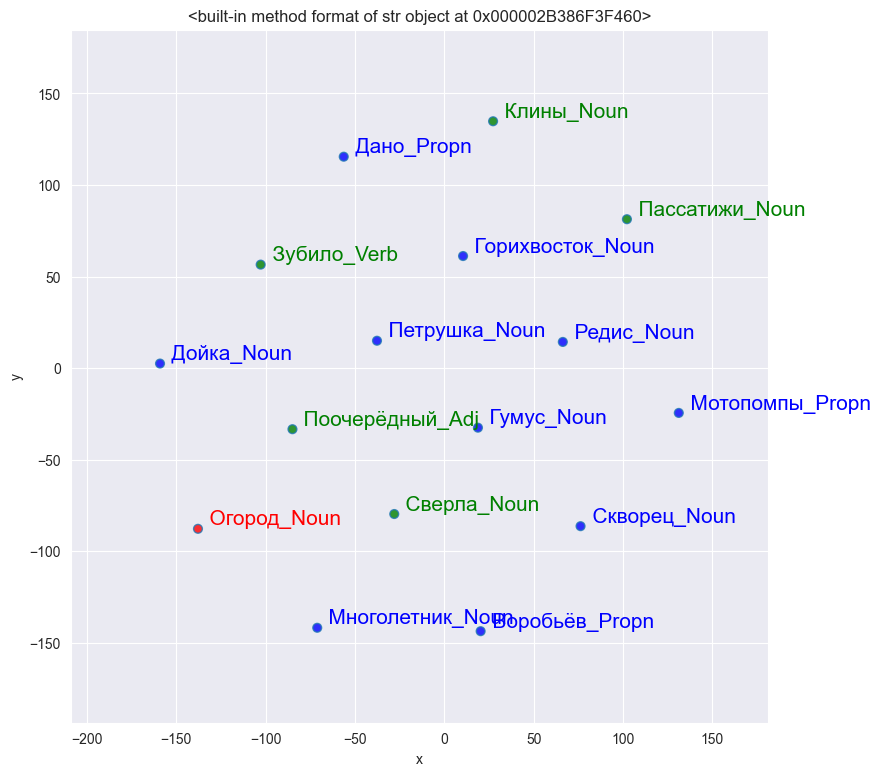

In [23]:
print(tsnescatterplot(model, 'огород_NOUN', [t[0] for t in model.wv.most_similar(positive=["молоток_NOUN"], topn=10)][5:]))

None


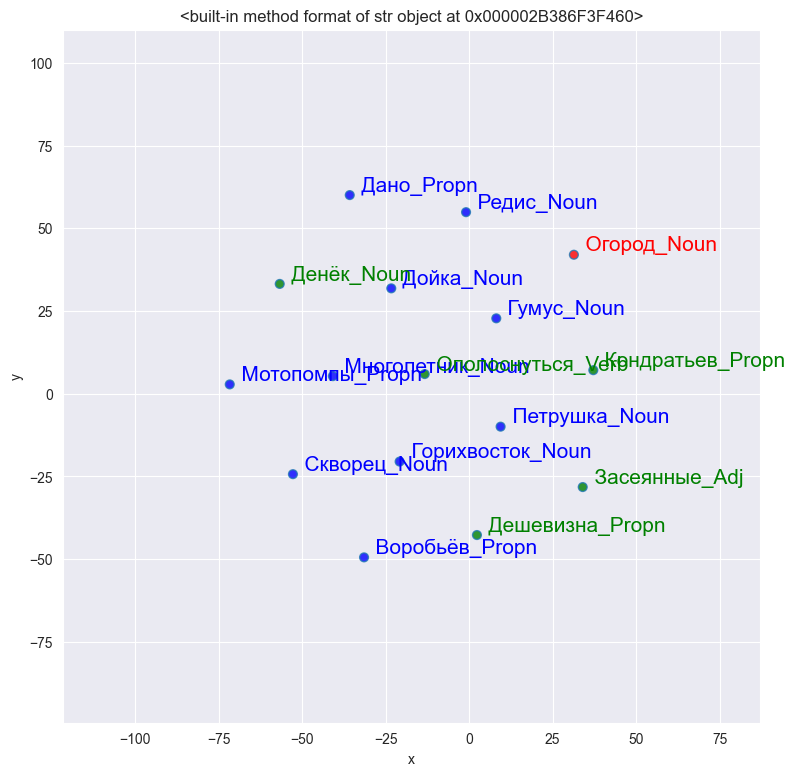

In [24]:
print(tsnescatterplot(model, 'огород_NOUN', [t[0] for t in model.wv.most_similar(positive=["сад_NOUN"], topn=10)][5:]))